In [1]:
import os
import sys
import glob
import cv2 as cv
import matplotlib.pyplot as plt
import numpy as np
import time
# from cfar import pycfar

lib_path = "../cfar/build"
if lib_path not in sys.path:
    sys.path.append(lib_path)

import pycfar


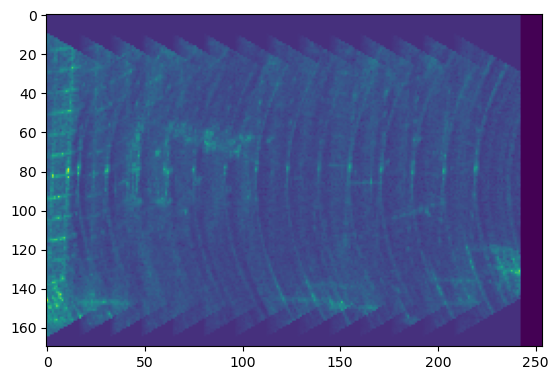

In [2]:
os.getcwd()
img_path = "/home/uwr/Desktop/final_image_.png"
img = cv.imread(img_path, cv.IMREAD_GRAYSCALE)
#img=cv.rotate(img,2)
plt.imshow(img)

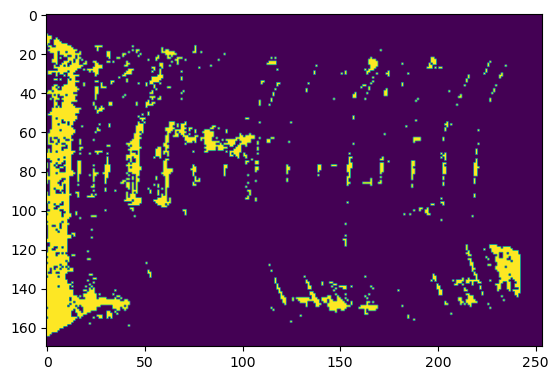

In [46]:
r,t=cv.threshold(img,70,255,cv.THRESH_BINARY)
plt.imshow(t)

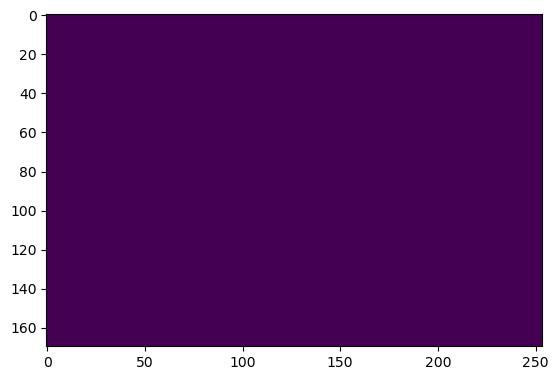

In [3]:
res = np.zeros_like(img)
res.shape
plt.imshow(res)


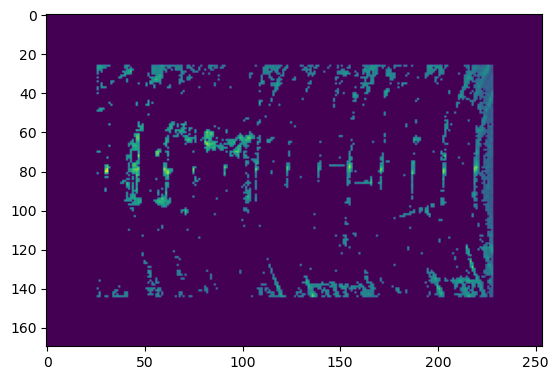

In [115]:
cfar_filter = pycfar.CFAR(40,10,0.4)
res1 = cfar_filter.soca_2d(img)
plt.imshow(res1)

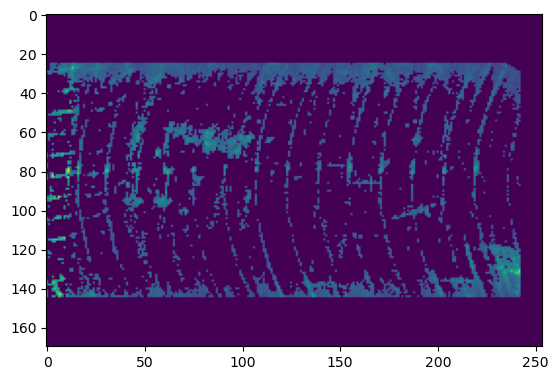

In [140]:
cfar_filter = pycfar.CFAR(40,10,0.13)
res2 = cfar_filter.soca_1d(img)
plt.imshow(res2)

In [105]:
res2.shape

(170, 254)

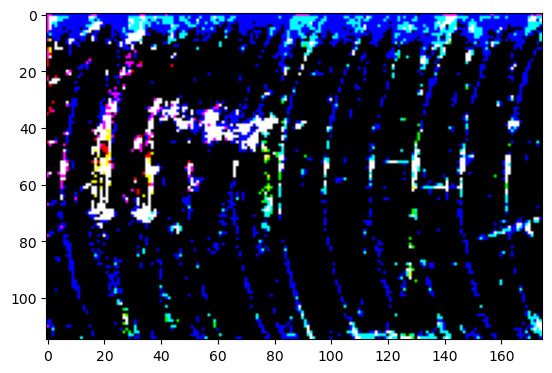

In [151]:
merge=cv.merge(([np.array(t[25:140,25:200]>0,np.uint8)*255,np.array(res1[25:140,25:200]>0,np.uint8)*255,np.array(res2[25:140,25:200]>0,np.uint8)*255]))
#plt.axes('off')
plt.imshow(merge)


In [13]:
count = 100
total = 0 
for _ in range(count):
    start_time = time.perf_counter()
    res = cfar_filter.soca_2d(img)
    end_time = time.perf_counter()
    total += end_time - start_time

# elapsed_time = end_time - start_time
elapsed_time = total/count
print(f"Function took: {elapsed_time:.6f} seconds")


Function took: 0.004176 seconds


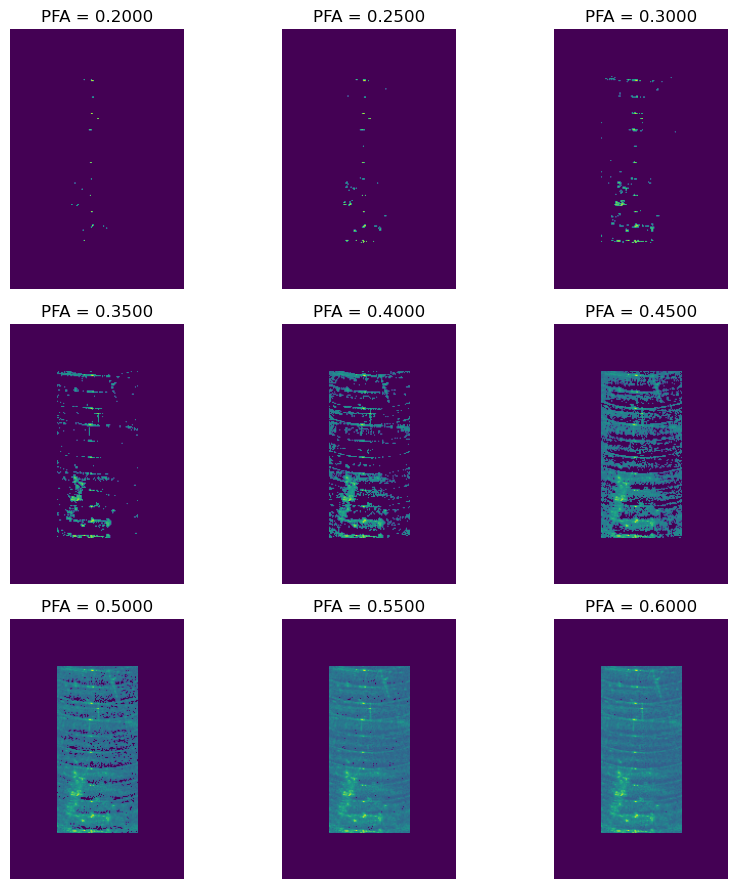

In [26]:
fig, axes = plt.subplots(3, 3, figsize=(9, 9))
axes = axes.flatten() # Flattens the 3x3 array of axes into a 1D array for easy iteration

for i,pfa in enumerate(np.arange(0.2,0.65,0.05)):
    cfar_filter = pycfar.CFAR(80,10,pfa)
    res = cfar_filter.soca_2d(img)
    axes[i].imshow(res)
    # Set the title of the subplot to the current PFA value, formatted to two decimal places
    axes[i].set_title(f'PFA = {pfa:.4f}')
    # Turn off the axis ticks and labels for a cleaner image display
    axes[i].axis('off')

plt.tight_layout()
plt.show()


IndexError: index 9 is out of bounds for axis 0 with size 9

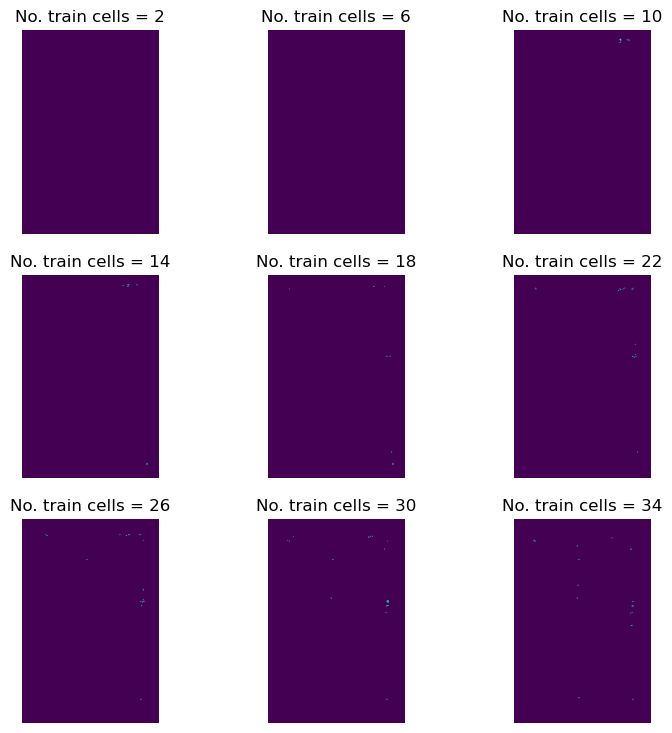

In [16]:
fig, axes = plt.subplots(3, 3, figsize=(9, 9))
axes = axes.flatten() # Flattens the 3x3 array of axes into a 1D array for easy iteration

for i,train_cells in enumerate(range(2,80,4)):
    cfar_filter = pycfar.CFAR(train_cells,10,0.2)
    res = cfar_filter.soca_2d(img)
    axes[i].imshow(res)
    # Set the title of the subplot to the current PFA value, formatted to two decimal places
    axes[i].set_title(f'No. train cells = {train_cells}')
    # Turn off the axis ticks and labels for a cleaner image display
    axes[i].axis('off')

plt.tight_layout()
plt.show()
